In [ ]:
# import packages
import numpy as np # NumPy is a Python package that stands for ‘Numerical Python’. It is the core library for scientific computing
import pandas as pd # Pandas is used for data manipulation, analysis and cleaning.
import matplotlib.pyplot as plt # powerful plotting library for python that offers a varied spectrum of 1D, 2D, and 3D visualizations.
from IPython.display import display, HTML, display_html # Display the HTML representation of an object.
import seaborn as sns # Seaborn is a data visualization library in Python based on matplotlib

In [ ]:
from pandas import read_csv #  imports a CSV file to DataFrame format.
# Load the dataset
data = pd.read_csv('diabetesafterpre.csv')

In [ ]:
data

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,0.608696,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
1,0.362319,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0
2,0.420290,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,0.594203,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
4,0.724638,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201,0.550725,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
202,0.333333,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
203,0.463768,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0
204,0.231884,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif, RFE
from sklearn.metrics import accuracy_score

# Load the dataset
data = pd.read_csv('diabetesafterpre.csv')

# Separate features and target
X = data.drop(columns=['class'])  # Features
y = data['class']  # Target variable

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Filter-Based Feature Selection
best_features = SelectKBest(score_func=mutual_info_classif, k='all')  # Initialize selector
best_features.fit(X_train, y_train)  # Fit to training data
scores = best_features.scores_  # Get feature scores

# Select top features based on threshold (e.g., median score)
threshold = np.median(scores)  # Calculate threshold
selected_features_filter = [feature for score, feature in zip(scores, X.columns) if score >= threshold]  # Filter features
print(f"Selected features (Filter-Based): {selected_features_filter}")

# Subset data based on selected features
X_train_filter = X_train[selected_features_filter]  # Filter training data
X_test_filter = X_test[selected_features_filter]  # Filter testing data

# Wrapper-Based Feature Selection
model = RandomForestClassifier(random_state=42)  # Initialize model
rfe = RFE(estimator=model)  # Initialize RFE
rfe.fit(X_train, y_train)  # Fit RFE to training data
selected_features_wrapper = X_train.columns[rfe.support_].tolist()  # Get selected features
print(f"Selected features (Wrapper-Based): {selected_features_wrapper}")

# Subset data based on selected features
X_train_wrapper = X_train[selected_features_wrapper]  # Wrapper-selected training data
X_test_wrapper = X_test[selected_features_wrapper]  # Wrapper-selected testing data

# Evaluate models on selected features
# Filter-Based Evaluation
model.fit(X_train_filter, y_train)  # Train model on filter-selected features
y_pred_filter = model.predict(X_test_filter)  # Predict on test data
accuracy_filter = accuracy_score(y_test, y_pred_filter)  # Calculate accuracy
print(f"Accuracy with Filter-Based Features: {accuracy_filter}")

# Wrapper-Based Evaluation
model.fit(X_train_wrapper, y_train)  # Train model on wrapper-selected features
y_pred_wrapper = model.predict(X_test_wrapper)  # Predict on test data
accuracy_wrapper = accuracy_score(y_test, y_pred_wrapper)  # Calculate accuracy
print(f"Accuracy with Wrapper-Based Features: {accuracy_wrapper}")



Selected features (Filter-Based): ['Gender', 'Polyuria', 'Polydipsia', 'sudden weight loss', 'visual blurring', 'Itching', 'partial paresis', 'Obesity']
Selected features (Wrapper-Based): ['Age', 'Gender', 'Polyuria', 'Polydipsia', 'sudden weight loss', 'Itching', 'partial paresis', 'Alopecia']
Accuracy with Filter-Based Features: 0.8809523809523809
Accuracy with Wrapper-Based Features: 0.8809523809523809


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state=42)
X_train.shape

(164, 16)

In [ ]:
# Recursive feature elimination with cross validation (RFECV) and random forest classification
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestClassifier

clf_rf_4 = RandomForestClassifier(random_state=42)
rfecv = RFECV(estimator=clf_rf_4, step=1, cv=10,scoring='accuracy')   #5-fold cross-validation
rfecv = rfecv.fit(X_train, y_train)

print('Optimal number of features :', rfecv.n_features_)

# Get the original feature names from 'X' (DataFrame) before scaling
original_feature_names = X.columns

# Use original_feature_names to get the selected feature names
print('Best features :', list(original_feature_names[rfecv.support_]))

Optimal number of features : 15
Best features : ['Age', 'Gender', 'Polyuria', 'Polydipsia', 'sudden weight loss', 'weakness', 'Polyphagia', 'Genital thrush', 'visual blurring', 'Itching', 'Irritability', 'delayed healing', 'partial paresis', 'muscle stiffness', 'Alopecia']


In [ ]:
data.drop('Obesity',axis = 1,inplace = True) # dropping of the "Obesity" feature from the dataset

In [ ]:
data.shape

(206, 16)

In [ ]:
data.to_csv("diabetesafterdropping.csv", index = False) # Modifying the dataset after dropping "Obesity" feature

In [ ]:
data = pd.read_csv('diabetesafterdropping.csv')

In [ ]:
# Separate features and target
X1 = data.drop(columns=['class'])  # Features
y1 = data['class']  # Target variable

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X1,y1,test_size = 0.2,random_state=42)
X_train.shape


(164, 15)

In [ ]:
X_test.shape


(42, 15)

In [ ]:
y_train.shape


(164,)

In [ ]:
y_test.shape

(42,)

In [ ]:
# Building of Logistic Regression Model
from sklearn.linear_model import LogisticRegression
lg=LogisticRegression()
lg.fit(X_train,y_train)

LogisticRegression()

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
param_grid = {
    'C': [0.1, 1, 10, 100,1000],
    'gamma': [1, 0.5, 0.1, 0.05, 0.01, 0.001, 0.0001],
    'kernel': ['rbf', 'linear','sigmoid']
}

grid_search = GridSearchCV(svm.SVC(), param_grid, cv=5, verbose=2, n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

Fitting 5 folds for each of 105 candidates, totalling 525 fits
Best Parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}


In [ ]:
# Predicting the values of X_test
y_pred = lg.predict(X_test)

In [ ]:
# Generation of confusion matrix and classification report with accuracy, precsion, recall, f1-score and support
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[14  3]
 [ 3 22]]
              precision    recall  f1-score   support

         0.0       0.82      0.82      0.82        17
         1.0       0.88      0.88      0.88        25

    accuracy                           0.86        42
   macro avg       0.85      0.85      0.85        42
weighted avg       0.86      0.86      0.86        42



In [ ]:
%matplotlib inline

In [ ]:
cmlg=confusion_matrix(y_test, y_pred)

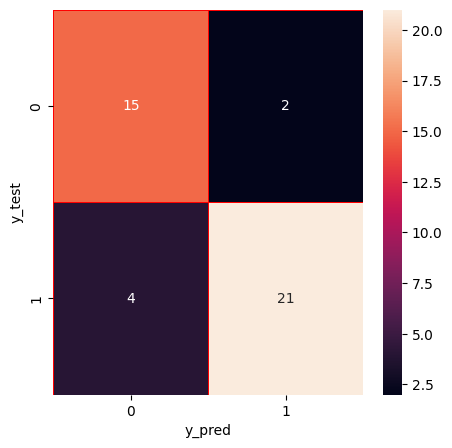

In [ ]:
f, ax=plt.subplots(figsize=(5,5))
sns.heatmap(cmlg,annot=True,linewidths=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_test")
plt.show()

In [ ]:
# Building of Logistic Regression Model
from sklearn.linear_model import LogisticRegression
lg=LogisticRegression(C=1.0, penalty='l2', solver='liblinear', class_weight='balanced', max_iter=500)
lg.fit(X_train,y_train)

LogisticRegression(class_weight='balanced', max_iter=500, solver='liblinear')

In [ ]:
# Predicting the values of X_test
y_pred = lg.predict(X_test)

In [ ]:
# Generation of confusion matrix and classification report with accuracy, precsion, recall, f1-score and support
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[15  2]
 [ 4 21]]
              precision    recall  f1-score   support

         0.0       0.79      0.88      0.83        17
         1.0       0.91      0.84      0.88        25

    accuracy                           0.86        42
   macro avg       0.85      0.86      0.85        42
weighted avg       0.86      0.86      0.86        42



In [ ]:
cmlg=confusion_matrix(y_test, y_pred)

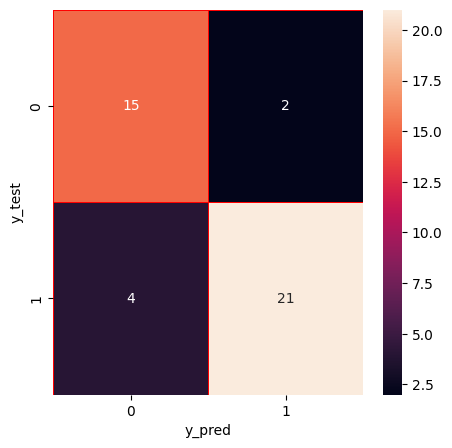

In [ ]:
f, ax=plt.subplots(figsize=(5,5))
sns.heatmap(cmlg,annot=True,linewidths=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_test")
plt.show()

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors=1)
classifier.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

In [ ]:
y_pred = classifier.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[17  0]
 [ 2 23]]
              precision    recall  f1-score   support

         0.0       0.89      1.00      0.94        17
         1.0       1.00      0.92      0.96        25

    accuracy                           0.95        42
   macro avg       0.95      0.96      0.95        42
weighted avg       0.96      0.95      0.95        42



In [ ]:
cmknn=confusion_matrix(y_test, y_pred)

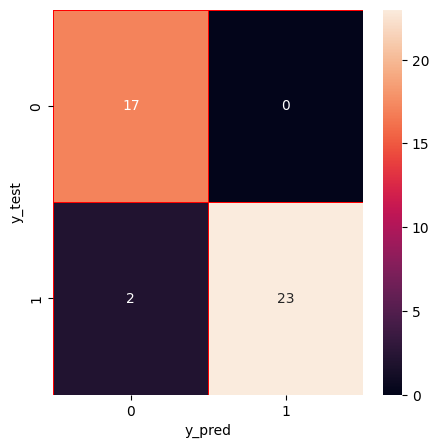

In [ ]:
f, ax=plt.subplots(figsize=(5,5))
sns.heatmap(cmknn,annot=True,linewidths=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_test")
plt.show()

In [ ]:
from sklearn import svm
svm_classifier = svm.SVC(kernel='linear')
svm_classifier.fit(X_train, y_train)

SVC(kernel='linear')

In [ ]:
y_predict = svm_classifier.predict(X_test)

In [ ]:
print(confusion_matrix(y_test, y_predict))
print(classification_report(y_test, y_predict))

[[14  3]
 [ 3 22]]
              precision    recall  f1-score   support

         0.0       0.82      0.82      0.82        17
         1.0       0.88      0.88      0.88        25

    accuracy                           0.86        42
   macro avg       0.85      0.85      0.85        42
weighted avg       0.86      0.86      0.86        42



In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
param_grid = {
    'C': [0.1, 1, 10, 100,1000],
    'gamma': [1, 0.5, 0.1, 0.05, 0.01, 0.001, 0.0001],
    'kernel': ['rbf', 'linear','sigmoid']
}

grid_search = GridSearchCV(svm.SVC(), param_grid, cv=5, verbose=2, n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

Fitting 5 folds for each of 105 candidates, totalling 525 fits
Best Parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}


In [ ]:
best_svm = grid_search.best_estimator_  # Use random_search.best_estimator_ if using Randomized Search
y_pred_best = best_svm.predict(X_test)

print("Best Model Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best))
print("Best Model Classification Report:\n", classification_report(y_test, y_pred_best))

Best Model Confusion Matrix:
 [[15  2]
 [ 3 22]]
Best Model Classification Report:
               precision    recall  f1-score   support

         0.0       0.83      0.88      0.86        17
         1.0       0.92      0.88      0.90        25

    accuracy                           0.88        42
   macro avg       0.88      0.88      0.88        42
weighted avg       0.88      0.88      0.88        42



In [ ]:
!pip install scipy # install module if necessary
from scipy.stats import uniform

In [ ]:
param_dist = {
    'C': uniform(0.1, 100),
    'gamma': uniform(0.001, 1),
    'kernel': ['rbf', 'linear', 'sigmoid']
}

random_search = RandomizedSearchCV(svm.SVC(), param_distributions=param_dist, n_iter=10, cv=5, verbose=2, n_jobs=-1, random_state=42)
random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'C': np.float64(15.699452033620265), 'gamma': np.float64(0.05908361216819946), 'kernel': 'rbf'}


In [ ]:
best_svm = random_search.best_estimator_  # Use random_search.best_estimator_ if using Randomized Search
y_pred_best = best_svm.predict(X_test)

print("Best Model Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best))
print("Best Model Classification Report:\n", classification_report(y_test, y_pred_best))

Best Model Confusion Matrix:
 [[15  2]
 [ 3 22]]
Best Model Classification Report:
               precision    recall  f1-score   support

         0.0       0.83      0.88      0.86        17
         1.0       0.92      0.88      0.90        25

    accuracy                           0.88        42
   macro avg       0.88      0.88      0.88        42
weighted avg       0.88      0.88      0.88        42



In [ ]:
from sklearn import svm
svm_classifier = svm.SVC(kernel='rbf')
svm_classifier.fit(X_train, y_train)

SVC()

In [ ]:
y_predict = svm_classifier.predict(X_test)

In [ ]:
print(confusion_matrix(y_test, y_predict))
print(classification_report(y_test, y_predict))

[[15  2]
 [ 3 22]]
              precision    recall  f1-score   support

         0.0       0.83      0.88      0.86        17
         1.0       0.92      0.88      0.90        25

    accuracy                           0.88        42
   macro avg       0.88      0.88      0.88        42
weighted avg       0.88      0.88      0.88        42

